<a href="https://colab.research.google.com/github/pinarrcindemirr/Development-of-and-End-to-End-NLP-Pipeline-for-Chatbot-Design-Support/blob/main/Q1122408_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LOAD DATA

In [1]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.text import Text

In [2]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
!git clone https://github.com/PolyAI-LDN/task-specific-datasets.git

fatal: destination path 'task-specific-datasets' already exists and is not an empty directory.


In [4]:
import os

os.listdir("task-specific-datasets")

['banking_data',
 'span_extraction',
 'LICENSE',
 'nlupp',
 'polyai-logo.png',
 'README.md',
 '.git']

# Data Description

In [5]:
import pandas as pd

train_df = pd.read_csv("task-specific-datasets/banking_data/train.csv")
test_df = pd.read_csv("task-specific-datasets/banking_data/test.csv")

In [6]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10003, 2)
Test shape: (3080, 2)


In [7]:
train_df["text"].head(10)

,text
0,I am still waiting on my card?
1,What can I do if my card still hasn't arrived ...
2,I have been waiting over a week. Is the card s...
3,Can I track my card while it is in the process...
4,"How do I know if I will get my card, or if it ..."
5,When did you send me my new card?
6,Do you have info about the card on delivery?
7,What do I do if I still have not received my n...
8,Does the package with my card have tracking?
9,I ordered my card but it still isn't here


In [8]:
train_df.head()
train_df.info()
train_df.sample(5)[["text", "category"]]
train_df["category"].value_counts().head()
train_df["category"].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      10003 non-null  object
 1   category  10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


77

In [9]:
sample_text = train_df["text"][0]

tokens = word_tokenize(sample_text)
tokens = [word.lower() for word in tokens]

print(tokens[:20])

t = Text(tokens)
t

['i', 'am', 'still', 'waiting', 'on', 'my', 'card', '?']


<Text: i am still waiting on my card ?...>

# PREPROCESSING

## NLTK

In [11]:
for i in range(3):
    text = train_df["text"][i]

    tokens = word_tokenize(text)
    tokens = [word.lower() for word in tokens]

    print(f"\nText {i+1}: {text}")
    print(f"Tokens: {tokens[:20]}")


Text 1: I am still waiting on my card?
Tokens: ['i', 'am', 'still', 'waiting', 'on', 'my', 'card', '?']

Text 2: What can I do if my card still hasn't arrived after 2 weeks?
Tokens: ['what', 'can', 'i', 'do', 'if', 'my', 'card', 'still', 'has', "n't", 'arrived', 'after', '2', 'weeks', '?']

Text 3: I have been waiting over a week. Is the card still coming?
Tokens: ['i', 'have', 'been', 'waiting', 'over', 'a', 'week', '.', 'is', 'the', 'card', 'still', 'coming', '?']


In [12]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
for i in range(3):
    text = train_df["text"][i]

    tokens = word_tokenize(text)
    tokens = [word.lower() for word in tokens]

    # STOPWORD REMOVAL
    filtered_tokens = [w for w in tokens if w not in stop_words]

    print(f"\nText {i+1}: {text}")
    print(f"Tokens: {tokens[:20]}")
    print(f"After Stopword Removal: {filtered_tokens[:20]}")


Text 1: I am still waiting on my card?
Tokens: ['i', 'am', 'still', 'waiting', 'on', 'my', 'card', '?']
After Stopword Removal: ['still', 'waiting', 'card', '?']

Text 2: What can I do if my card still hasn't arrived after 2 weeks?
Tokens: ['what', 'can', 'i', 'do', 'if', 'my', 'card', 'still', 'has', "n't", 'arrived', 'after', '2', 'weeks', '?']
After Stopword Removal: ['card', 'still', "n't", 'arrived', '2', 'weeks', '?']

Text 3: I have been waiting over a week. Is the card still coming?
Tokens: ['i', 'have', 'been', 'waiting', 'over', 'a', 'week', '.', 'is', 'the', 'card', 'still', 'coming', '?']
After Stopword Removal: ['waiting', 'week', '.', 'card', 'still', 'coming', '?']


In [14]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
lemmatizer = WordNetLemmatizer()

print(lemmatizer.lemmatize('brightening'))
print(lemmatizer.lemmatize('boxes'))
print(lemmatizer.lemmatize('brightening', pos='v'))

for i in range(3):
    text = train_df["text"][i]

    tokens = word_tokenize(text)
    tokens = [word.lower() for word in tokens]

    # Stopword removal
    filtered_tokens = [w for w in tokens if w not in stop_words]

    # Lemmatization using WordNetLemmatizer
    lemmatized_tokens = [lemmatizer.lemmatize(w) for w in filtered_tokens]

    print(f"\nText {i+1}: {text}")
    print(f"After Stopword Removal: {filtered_tokens[:20]}")
    print(f"After Lemmatization: {lemmatized_tokens[:20]}")

brightening
box
brighten

Text 1: I am still waiting on my card?
After Stopword Removal: ['still', 'waiting', 'card', '?']
After Lemmatization: ['still', 'waiting', 'card', '?']

Text 2: What can I do if my card still hasn't arrived after 2 weeks?
After Stopword Removal: ['card', 'still', "n't", 'arrived', '2', 'weeks', '?']
After Lemmatization: ['card', 'still', "n't", 'arrived', '2', 'week', '?']

Text 3: I have been waiting over a week. Is the card still coming?
After Stopword Removal: ['waiting', 'week', '.', 'card', 'still', 'coming', '?']
After Lemmatization: ['waiting', 'week', '.', 'card', 'still', 'coming', '?']


## spaCy

In [16]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [17]:
for i in range(3):
    text = train_df["text"][i]
    doc = nlp(text)

    tokens = [token.text.lower() for token in doc]

    print(f"\nText {i+1}: {text}")
    print(f"spaCy Tokens: {tokens[:20]}")


Text 1: I am still waiting on my card?
spaCy Tokens: ['i', 'am', 'still', 'waiting', 'on', 'my', 'card', '?']

Text 2: What can I do if my card still hasn't arrived after 2 weeks?
spaCy Tokens: ['what', 'can', 'i', 'do', 'if', 'my', 'card', 'still', 'has', "n't", 'arrived', 'after', '2', 'weeks', '?']

Text 3: I have been waiting over a week. Is the card still coming?
spaCy Tokens: ['i', 'have', 'been', 'waiting', 'over', 'a', 'week', '.', 'is', 'the', 'card', 'still', 'coming', '?']


In [18]:
for i in range(3):
    text = train_df["text"][i]
    doc = nlp(text)

    filtered_tokens = [
        token.text.lower()
        for token in doc
        if not token.is_stop
    ]

    print(f"\nText {i+1}: {text}")
    print(f"After Stopword Removal: {filtered_tokens[:20]}")


Text 1: I am still waiting on my card?
After Stopword Removal: ['waiting', 'card', '?']

Text 2: What can I do if my card still hasn't arrived after 2 weeks?
After Stopword Removal: ['card', 'arrived', '2', 'weeks', '?']

Text 3: I have been waiting over a week. Is the card still coming?
After Stopword Removal: ['waiting', 'week', '.', 'card', 'coming', '?']


In [19]:
for i in range(3):
    text = train_df["text"][i]
    doc = nlp(text)

    lemmatized_tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
    ]

    print(f"\nText {i+1}: {text}")
    print(f"After Lemmatization: {lemmatized_tokens[:20]}")


Text 1: I am still waiting on my card?
After Lemmatization: ['wait', 'card', '?']

Text 2: What can I do if my card still hasn't arrived after 2 weeks?
After Lemmatization: ['card', 'arrive', '2', 'week', '?']

Text 3: I have been waiting over a week. Is the card still coming?
After Lemmatization: ['wait', 'week', '.', 'card', 'come', '?']


In [20]:
for i in range(3):
    text = train_df["text"][i]
    doc = nlp(text)

    processed_tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct
    ]

    print(f"\nText {i+1}: {text}")
    print(f"Processed with spaCy: {processed_tokens[:20]}")


Text 1: I am still waiting on my card?
Processed with spaCy: ['wait', 'card']

Text 2: What can I do if my card still hasn't arrived after 2 weeks?
Processed with spaCy: ['card', 'arrive', '2', 'week']

Text 3: I have been waiting over a week. Is the card still coming?
Processed with spaCy: ['wait', 'week', 'card', 'come']


## NER using spaCy

In [21]:
for i in range(50):
    text = train_df["text"][i]
    doc = nlp(text)

    if len(doc.ents) > 0:
        print(f"\nIndex {i}: {text}")
        for ent in doc.ents:
            print(ent.text, "->", ent.label_)


Index 1: What can I do if my card still hasn't arrived after 2 weeks?
2 weeks -> DATE

Index 2: I have been waiting over a week. Is the card still coming?
a week -> DATE

Index 11: I still haven't received my card after two weeks, is it lost?
two weeks -> DATE

Index 14: It's been a week since I ordered my card and it's not here. Please help?
a week -> DATE

Index 16: I don't have my card in 1 week.  Should I be worried?
1 week -> DATE

Index 19: It's been a week since you issued me a card and I still didn't get it. Should I keep waiting?
a week -> DATE

Index 25: It's been a week since you sent my card and I still don't have it.
a week -> DATE

Index 34: Where is the card I ordered 2 weeks ago?
2 weeks ago -> DATE


In [22]:
from spacy import displacy

text = train_df["text"][1]
doc = nlp(text)

displacy.render(doc, style="ent", jupyter=True)

##  Keeping vs Removing Stopwords

In [23]:
from collections import Counter
from nltk.tokenize import word_tokenize

all_tokens_no_stop = []

for text in train_df["text"]:
    tokens = word_tokenize(text.lower())
    all_tokens_no_stop.extend(tokens)

freq_no_stop = Counter(all_tokens_no_stop)

print(freq_no_stop.most_common(10))

[('i', 8802), ('?', 6505), ('my', 5684), ('.', 4288), ('to', 4038), ('a', 3565), ('the', 3497), ('card', 2682), ('is', 2534), ('do', 2151)]


In [24]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

all_tokens_with_stop_removed = []

for text in train_df["text"]:
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w not in stop_words]
    all_tokens_with_stop_removed.extend(tokens)

freq_with_stop_removed = Counter(all_tokens_with_stop_removed)

print(freq_with_stop_removed.most_common(10))

[('?', 6505), ('.', 4288), ('card', 2682), ("n't", 1581), (',', 1561), ('account', 1351), ('money', 1133), ('transfer', 1083), ('get', 808), ('payment', 750)]


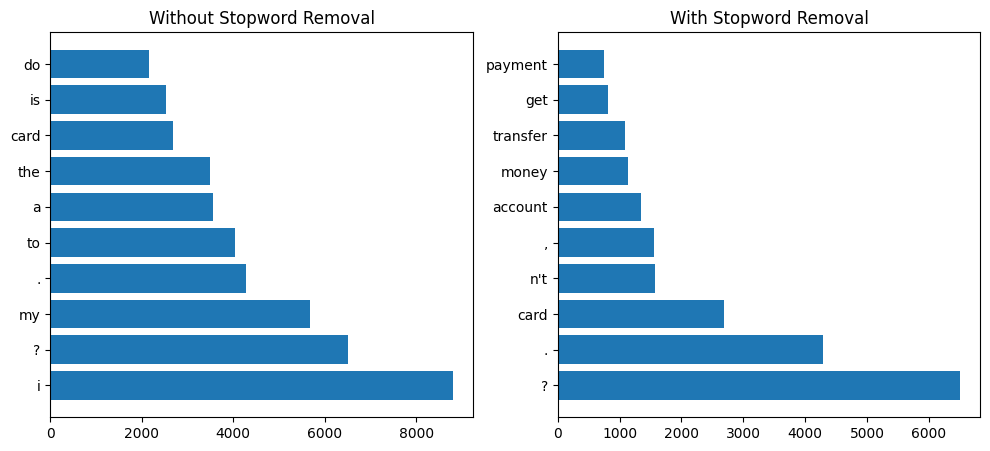

In [25]:
top10_no_stop = dict(freq_no_stop.most_common(10))
top10_with_stop = dict(freq_with_stop_removed.most_common(10))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.barh(list(top10_no_stop.keys()), list(top10_no_stop.values()))
plt.title("Without Stopword Removal")

plt.subplot(1,2,2)
plt.barh(list(top10_with_stop.keys()), list(top10_with_stop.values()))
plt.title("With Stopword Removal")

plt.show()

# EXPLORATORY VISUALISATION

### Common User Intents

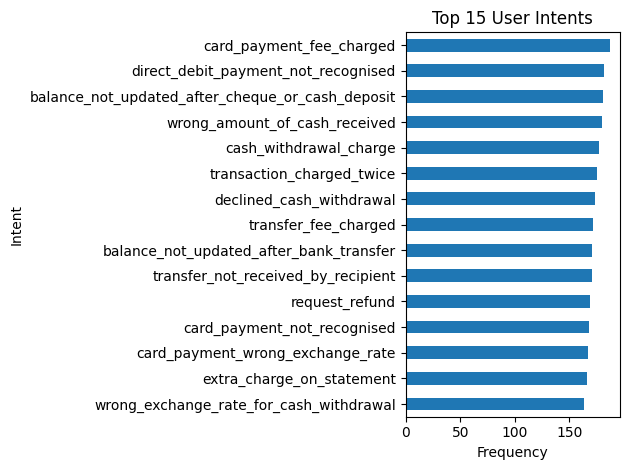

In [26]:
import matplotlib.pyplot as plt

top_intents = train_df["category"].value_counts().head(15)

plt.figure()

top_intents.sort_values().plot(kind="barh")

plt.title("Top 15 User Intents")
plt.xlabel("Frequency")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

### Token Frequency Chart

In [27]:
all_tokens = []

for text in train_df["text"]:
    tokens = word_tokenize(text)
    tokens = [w.lower() for w in tokens]
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [w for w in tokens if w.isalpha()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    all_tokens.extend(tokens)

In [28]:
from collections import Counter

token_counts = Counter(all_tokens)

top_tokens = token_counts.most_common(20)

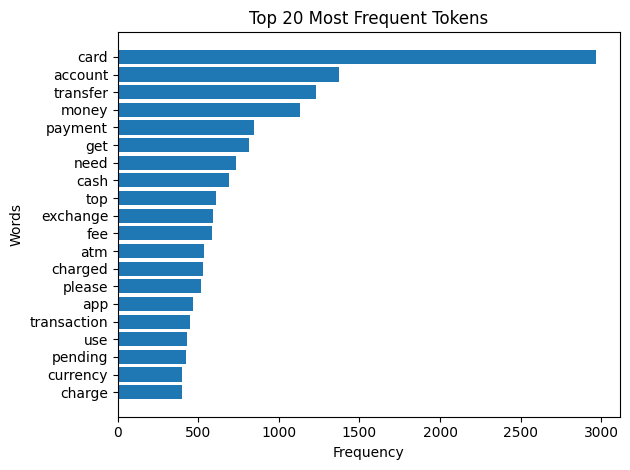

In [29]:
words = [w[0] for w in top_tokens]
counts = [w[1] for w in top_tokens]

plt.figure()

plt.barh(words, counts)

plt.title("Top 20 Most Frequent Tokens")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Entity Type Frequency Chart

In [30]:
entity_labels = []

for text in train_df["text"]:
    doc = nlp(text)

    for ent in doc.ents:
        entity_labels.append(ent.label_)

In [31]:
from collections import Counter

entity_counts = Counter(entity_labels)

top_entities = entity_counts.most_common(10)

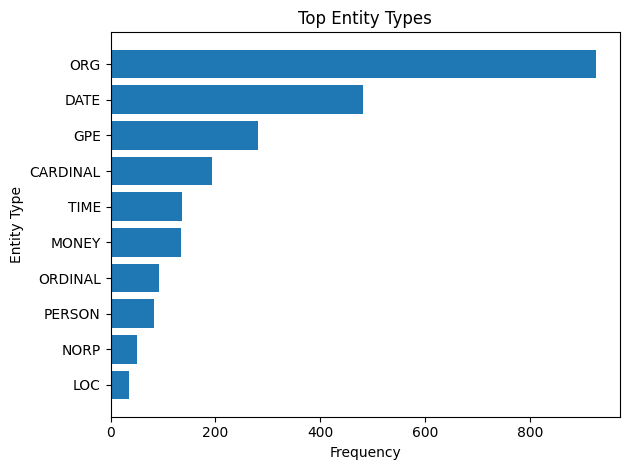

In [32]:
labels = [e[0] for e in top_entities]
counts = [e[1] for e in top_entities]

plt.figure()

plt.barh(labels, counts)

plt.title("Top Entity Types")
plt.xlabel("Frequency")
plt.ylabel("Entity Type")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## NLTK vs spaCy

In [33]:
text = train_df["text"][10]

print("Original Text:")
print(text)

tokens_nltk = word_tokenize(text)
tokens_nltk = [w.lower() for w in tokens_nltk]
tokens_nltk = [w for w in tokens_nltk if w not in stop_words]
tokens_nltk = [lemmatizer.lemmatize(w) for w in tokens_nltk]

print("\nNLTK Output:")
print(tokens_nltk)

doc = nlp(text)

tokens_spacy = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop and not token.is_punct
]

print("\nspaCy Output:")
print(tokens_spacy)

Original Text:
Why has my new card still not come?

NLTK Output:
['new', 'card', 'still', 'come', '?']

spaCy Output:
['new', 'card', 'come']


In [34]:
comparison_text = train_df["text"][10]

nltk_tokens = word_tokenize(comparison_text)
nltk_tokens = [w.lower() for w in nltk_tokens]
nltk_tokens = [w for w in nltk_tokens if w not in stop_words]
nltk_tokens = [w for w in nltk_tokens if w.isalpha()]
nltk_tokens = [lemmatizer.lemmatize(w) for w in nltk_tokens]

doc = nlp(comparison_text)
spacy_tokens = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop and not token.is_punct and token.is_alpha
]

comparison_table = pd.DataFrame({
    "Tool": ["NLTK", "spaCy"],
    "Token Count": [len(nltk_tokens), len(spacy_tokens)],
    "Vocabulary Size": [len(set(nltk_tokens)), len(set(spacy_tokens))],
    "Example Output": [nltk_tokens, spacy_tokens]
})

comparison_table

,Tool,Token Count,Vocabulary Size,Example Output
0,NLTK,4,4,"[new, card, still, come]"
1,spaCy,3,3,"[new, card, come]"


# Classical NLP Baseline for Intent Classification

## Convert text to numerical features using TF–IDF

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_text = train_df["text"]
y_train = train_df["category"]

X_test_text = test_df["text"]
y_test = test_df["category"]

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

vocabulary = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(vocabulary))
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

tfidf_array = X_train_tfidf[:3].toarray()

for i in range(3):
    print(f"\nSentence {i+1}: {X_train_text.iloc[i]}")

    tfidf_scores = {
        vocabulary[j]: round(score, 4)
        for j, score in enumerate(tfidf_array[i])
        if score > 0
    }

    print("TF-IDF Scores:", tfidf_scores)
    print("-" * 50)

Vocabulary size: 2320
Train TF-IDF shape: (10003, 2320)
Test TF-IDF shape: (3080, 2320)

Sentence 1: I am still waiting on my card?
TF-IDF Scores: {'am': np.float64(0.4312), 'card': np.float64(0.2479), 'my': np.float64(0.1775), 'on': np.float64(0.3661), 'still': np.float64(0.459), 'waiting': np.float64(0.6135)}
--------------------------------------------------

Sentence 2: What can I do if my card still hasn't arrived after 2 weeks?
TF-IDF Scores: {'after': np.float64(0.388), 'arrived': np.float64(0.4338), 'can': np.float64(0.1836), 'card': np.float64(0.1662), 'do': np.float64(0.199), 'hasn': np.float64(0.3516), 'if': np.float64(0.2966), 'my': np.float64(0.119), 'still': np.float64(0.3076), 'weeks': np.float64(0.4457), 'what': np.float64(0.2032)}
--------------------------------------------------

Sentence 3: I have been waiting over a week. Is the card still coming?
TF-IDF Scores: {'been': np.float64(0.2747), 'card': np.float64(0.1575), 'coming': np.float64(0.4675), 'have': np.float6

## Train a classical model

In [36]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=1000)

log_reg_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred = log_reg_model.predict(X_test_tfidf)

for i in range(5):
    print("Text:", X_test_text.iloc[i])
    print("True:", y_test.iloc[i])
    print("Predicted:", y_pred[i])
    print("-" * 50)

Text: How do I locate my card?
True: card_arrival
Predicted: card_linking
--------------------------------------------------
Text: I still have not received my new card, I ordered over a week ago.
True: card_arrival
Predicted: card_arrival
--------------------------------------------------
Text: I ordered a card but it has not arrived. Help please!
True: card_arrival
Predicted: card_arrival
--------------------------------------------------
Text: Is there a way to know when my card will arrive?
True: card_arrival
Predicted: card_arrival
--------------------------------------------------
Text: My card has not arrived yet.
True: card_arrival
Predicted: card_arrival
--------------------------------------------------


## Evaluation

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8769480519480519


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.85      0.88      0.86        40
                                activate_my_card       1.00      0.95      0.97        40
                                       age_limit       0.95      1.00      0.98        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       0.97      0.90      0.94        40
                                automatic_top_up       1.00      0.90      0.95        40
         balance_not_updated_after_bank_transfer       0.63      0.78      0.70        40
balance_not_updated_after_cheque_or_cash_deposit       0.84      0.95      0.89        40
                         beneficiary_not_allowed       0.94      0.85      0.89        40
                                 cancel_transfer       0.95      0.95      0.95        40
         

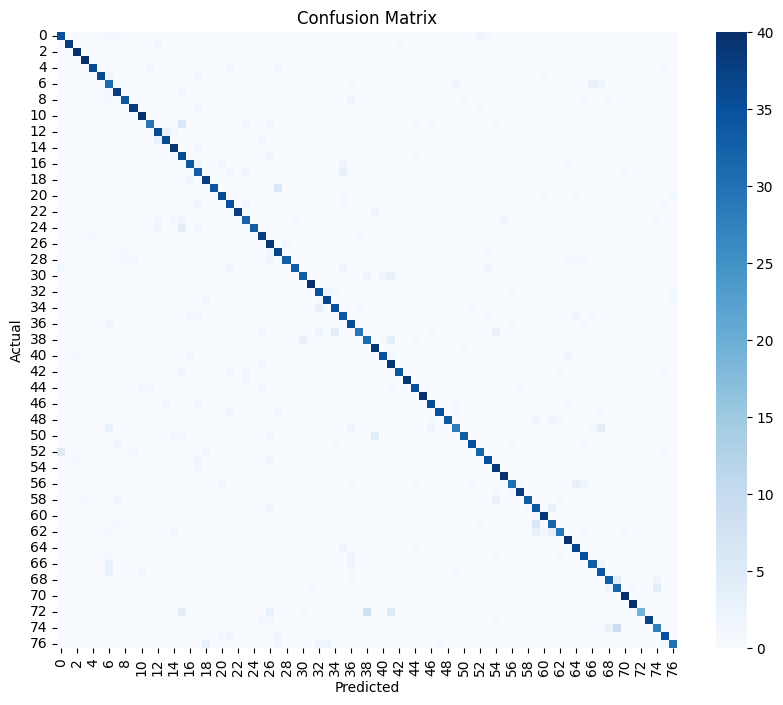

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
import pandas as pd
import numpy as np

cm = confusion_matrix(y_test, y_pred, labels=log_reg_model.classes_)

cm_df = pd.DataFrame(
    cm,
    index=log_reg_model.classes_,
    columns=log_reg_model.classes_
)

# Sadece hataları görmek için doğru tahminleri sıfırla
errors = cm_df.copy()
np.fill_diagonal(errors.values, 0)

top_errors = (
    errors.stack()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

top_errors.columns = ["Actual Intent", "Predicted Intent", "Error Count"]

top_errors

,Actual Intent,Predicted Intent,Error Count
0,why_verify_identity,verify_my_identity,9
1,virtual_card_not_working,get_disposable_virtual_card,8
2,top_up_reverted,top_up_failed,6
3,card_acceptance,card_not_working,6
4,card_swallowed,declined_cash_withdrawal,6
5,virtual_card_not_working,getting_virtual_card,5
6,request_refund,Refund_not_showing_up,5
7,verify_my_identity,why_verify_identity,4
8,virtual_card_not_working,card_not_working,4
9,pin_blocked,get_physical_card,4


##  Misclassified examples

In [42]:
import random

misclassified = []

for i in range(len(y_test)):
    if y_test.iloc[i] != y_pred[i]:
        misclassified.append({
            "text": X_test_text.iloc[i],
            "true": y_test.iloc[i],
            "pred": y_pred[i]
        })

sample_errors = random.sample(misclassified, 3)

for i, item in enumerate(sample_errors):
    print(f"Example {i+1}")
    print("Text:", item["text"])
    print("True:", item["true"])
    print("Predicted:", item["pred"])
    print("-" * 50)

Example 1
Text: how much you charge for exhcange
True: exchange_charge
Predicted: top_up_by_bank_transfer_charge
--------------------------------------------------
Example 2
Text: What methods can I use to add money to my account?
True: transfer_into_account
Predicted: supported_cards_and_currencies
--------------------------------------------------
Example 3
Text: Is GBP a supported currency?
True: receiving_money
Predicted: exchange_via_app
--------------------------------------------------


##  Logistic Regression vs Naive Bayes

In [43]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Model oluştur
nb_model = MultinomialNB()

# Eğit
nb_model.fit(X_train_tfidf, y_train)

# Tahmin
y_pred_nb = nb_model.predict(X_test_tfidf)

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Logistic Regression Accuracy:", accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)

Logistic Regression Accuracy: 0.8769480519480519
Naive Bayes Accuracy: 0.7886363636363637


In [44]:
print("Naive Bayes Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Report:

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.92      0.90      0.91        40
                                activate_my_card       0.63      0.95      0.76        40
                                       age_limit       1.00      0.95      0.97        40
                         apple_pay_or_google_pay       0.82      1.00      0.90        40
                                     atm_support       0.89      0.60      0.72        40
                                automatic_top_up       0.92      0.90      0.91        40
         balance_not_updated_after_bank_transfer       0.60      0.78      0.67        40
balance_not_updated_after_cheque_or_cash_deposit       0.69      0.93      0.79        40
                         beneficiary_not_allowed       0.81      0.88      0.84        40
                                 cancel_transfer       0.93      0.97      0.9

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
